## 1 - Business Understanding (Aufgabendefinition) 
- Bestimmung der betriebswirtschaftlichen Problemstellung
- Situationsbewertung
- Bestimmung analytischer Ziele
- Erstellung eines Projektplans
- ---

### Bestimmung der betriebswirtschaftlichen Problemstellung
Ein Gebrauchtwagenhändler (GWH) möchte den Preis für verfügbare Gebrauchtwagen mittels eines Modells bestimmen. Bisher wird der Preis auf Basis der Erfahrungswerte der Mitarbeiter bestimmt. Der Preis soll für die Kunden und im Vergleich zum Markt akzeptabel sein und gleichzeitig eine hohe Marge für den Händler einbringen. Durch den Einsatz einer datenbasierten Entscheidungsunterstützung soll gezeigt werden, ob es Potenzial für höhere Margen gibt. 
### Situationsbewertung
Der GWH hat Daten über verkaufte Gebrauchtwagen über die Plattform kaggle bezogen. Die Grundlage für eine Datenanalyse ist damit vorhanden. Der aktuelle Prozess ist stark von der Erfahrung der jeweiligen Mitarbeiter abhängig. Ein datenbasierter und systemgestützter Prozess könnte diese starke Abhängigkeit entlasten und die Mitarbeiter bei Ihren Entscheidungen unterstützen. Es besteht die Chance neue Erkenntnisse aus Daten zu erlangen und bisher ungenutzte Potenziale zu heben.
### Bestimmung analytischer Ziele
Identifizierung von Assoziationen in den Daten und deren Einfluss auf das Ziel-Attribut „Preis“ 
### Erstellung eines Projektplans
Zusammenstellen eines Teams (Rollen, Verantwortungen festlegen)
Vorgehen nach den CRISP-DM (Phasen und Dauer planen)
Ergebnisse dem Auftraggeber präsentieren

---

## 2 - Data Understanding (Datenverständniss)
- Daten sammeln
- Daten beschreiben
- Untersuchung der Daten
- Verifizierung der Datenqualität
- ---

### Import the data

In [18]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import data sets
df = pd.read_csv("toyota.csv")

# Data: Based on Used Car data from https://www.kaggle.com/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/data

---
## 3 - Data Preparation (Datenaufbereitung)
- Auswahl der Daten
- Bereinigung der Daten
- Transformation und Integration der Daten
- Datenformatierung
- ---

### Preprocess the Data

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)

# Define features and target
X = df.drop(columns=["price"])
y = df["price"]

# Preprocessing for numerical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_features = X.select_dtypes(include=["object"]).columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

---
## 4 - Modeling (Modellierung)
- Auswahl des Modells
- Testmodell erstellen
- Modell erstellen
- ---

### Build and Train the Model

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Create a pipeline that includes preprocessing and the regressor
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", MLPRegressor(hidden_layer_sizes=(100,), max_iter=3000, random_state=42, early_stopping=True, learning_rate_init=0.001))
])

# Train the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['year', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['model', 'transmission', 'fuelType'], dtype='object'))])),
                ('regressor',
                 MLPRegressor(early_stopping=True, max_iter=3000,
                              random_state=42))])

## 5 - Evaluation (Bewertung)
- Bewertung des Modells
- Bewertung der Resultate
- Bewertung des Prozesses
- Nächste Schritte festlegen

---

### Evaluate the Model

In [21]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
#rmse = mean_squared_error(y_test, y_pred, squared=False)
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")


Root Mean Squared Error: 1945.4580664138705
R² Score: 0.9110634630697587


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

print(X_train.dtypes)

# Angenommen, Spalten 0 und 3 sind kategorisch
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(), [0, 2, 4])],
    remainder='passthrough'
)

X_train_encoded = preprocessor.fit_transform(X_train)
import numpy as np
X_train_scaled = X_train_encoded.astype(np.float64)

from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
}
grid = GridSearchCV(MLPRegressor(max_iter=3000, early_stopping=True), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)

model            object
year              int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object


c:\Users\sangermann\anaconda3\envs\dssec2\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


### Visualize the Results

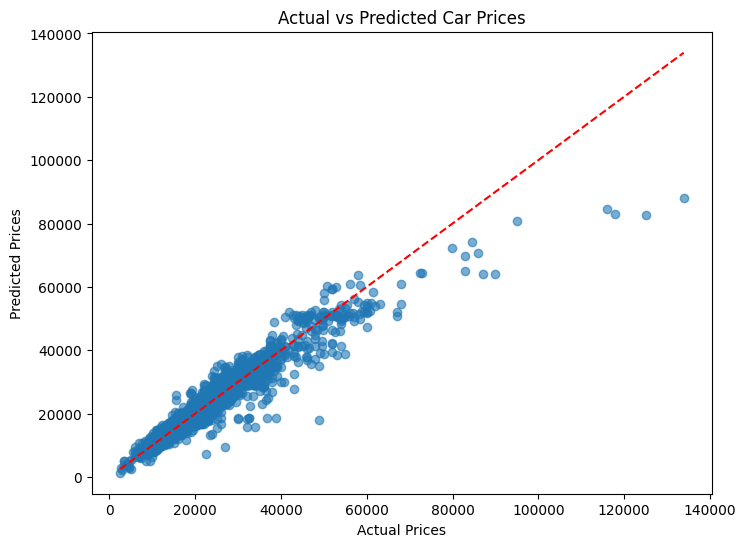

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.show()


## 6 - Deployment (Anwendung)
- Zusammenfassender Bericht und Präsentation der Ergebnisse
- Implementierungs-strategie planen
- Überwachung der Gültigkeit der Modelle planen
- ---

In [ ]:
print("Making predictions for the following 5 cars:")
print(X.head())
print("The predictions are")
print(model.predict(X.head()))

Making predictions for the following 5 cars:
  model  year transmission  mileage fuelType  tax   mpg  engineSize
0    A1  2017       Manual    15735   Petrol  150  55.4         1.4
1    A6  2016    Automatic    36203   Diesel   20  64.2         2.0
2    A1  2016       Manual    29946   Petrol   30  55.4         1.4
3    A4  2017    Automatic    25952   Diesel  145  67.3         2.0
4    A3  2019       Manual     1998   Petrol  145  49.6         1.0
The predictions are
[15178.51759016 17415.0243746  12718.03919921 18757.77555218
 19627.66539166]


In [ ]:
import pandas as pd

# DataFrame erstellen
results_df = pd.DataFrame({
    "Echter Wert": y_test,
    "Vorhergesagt": y_pred
})

# Optional: Differenz hinzufügen
results_df["Abweichung"] = results_df["Echter Wert"] - results_df["Vorhergesagt"]

# Die ersten Zeilen anzeigen
print(results_df.head(10))  # Zeigt 10 Beispiele
results_df.sort_values(by="Abweichung", key=abs, ascending=False)

       Echter Wert  Vorhergesagt   Abweichung
10442         9990   9360.405506   629.594494
2907         22382  20786.413192  1595.586808
7388         28990  29831.201088  -841.201088
3016         30777  27275.698159  3501.301841
7890         14950  14646.012919   303.987081
483          24365  22339.002409  2025.997591
5799         30495  35540.288364 -5045.288364
6026         29900  30426.573120  -526.573120
1084         15256  15464.610563  -208.610563
7873         24950  27621.265682 -2671.265682


,Echter Wert,Vorhergesagt,Abweichung
5459,133900,92749.571419,41150.428581
10468,125000,87001.353412,37998.646588
7644,48800,17383.650169,31416.349831
4742,117990,87451.747040,30538.252960
5707,116000,89149.340870,26850.659130
...,...,...,...
1498,26888,26890.880865,-2.880865
10264,11000,10997.372469,2.627531
2145,8895,8892.471324,2.528676
9567,28950,28951.953151,-1.953151


In [ ]:
results_df.to_csv("vorhersagen_knn.csv", index=False)